# KNN — Exercícios de Revisão e Fixação
**Aprendizagem de Máquina** · Implementação do K-Nearest Neighbors usando apenas **NumPy** e **Matplotlib**.

Em cada exercício: (1) carregamos e visualizamos os dados, (2) classificamos com o KNN, (3) medimos o desempenho com *leave-one-out* (cada ponto é classificado usando todos os outros), (4) desenhamos a fronteira de decisão para vários valores de `k` e (5) respondemos aos quesitos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('seaborn-v0_8-whitegrid')
CORES = {1: 'tab:blue', 2: 'tab:orange', 3: 'tab:red'}

## Funções do KNN (usadas nos 3 exercícios)

In [2]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))

def vizinhos_mais_proximos(X, y, ponto, k, ignorar=None):
    """Rótulos e distâncias dos k vizinhos mais próximos de `ponto`.
    `ignorar` é o índice de um ponto de X a desconsiderar (usado no leave-one-out)."""
    d = distancia_euclidiana(X, ponto)
    if ignorar is not None:
        d = d.copy()
        d[ignorar] = np.inf
    idx = np.argsort(d, kind='stable')[:k]
    return y[idx], d[idx]

def prever(X, y, ponto, k, ignorar=None):
    rotulos, _ = vizinhos_mais_proximos(X, y, ponto, k, ignorar)
    return np.bincount(rotulos).argmax()          # voto majoritário

def normalizar(X, media, desvio):
    return (X - media) / desvio                   # padronização (z-score)

def acuracia_loo(X, y, k):
    """Leave-one-out: classifica cada ponto usando todos os demais."""
    pred = np.array([prever(X, y, X[i], k, ignorar=i) for i in range(len(X))])
    return np.mean(pred == y), pred

def matriz_confusao(y, pred, classes=(1, 2, 3)):
    M = np.zeros((len(classes), len(classes)), dtype=int)
    for real, p in zip(y, pred):
        M[classes.index(real), classes.index(p)] += 1
    return M

def carregar(arquivo):
    dados = np.loadtxt(arquivo, delimiter=',', skiprows=1)
    return dados[:, :2], dados[:, 2].astype(int)

### Funções de visualização

In [3]:
def plotar_dados(X, y, nomes, rotulos, titulo, novo=None):
    fig, ax = plt.subplots(figsize=(9, 6))
    for c in (1, 2, 3):
        ax.scatter(X[y == c, 0], X[y == c, 1], c=CORES[c], s=90, edgecolor='k',
                   alpha=.8, label=rotulos[c])
    if novo is not None:
        ax.scatter(*novo, c='green', marker='*', s=350, edgecolor='k', label='Novo ponto')
    ax.set_xlabel(nomes[0]); ax.set_ylabel(nomes[1]); ax.set_title(titulo); ax.legend()
    plt.show()

def plotar_fronteiras(X, y, nomes, ks, titulo, padronizar=True, novo=None):
    """Desenha a região que o KNN atribuiria a cada classe, para cada k."""
    media, desvio = (X.mean(0), X.std(0)) if padronizar else (np.zeros(2), np.ones(2))
    Z = normalizar(X, media, desvio)
    gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - .05 * np.ptp(X[:, 0]), X[:, 0].max() + .05 * np.ptp(X[:, 0]), 120),
                         np.linspace(X[:, 1].min() - .05 * np.ptp(X[:, 1]), X[:, 1].max() + .05 * np.ptp(X[:, 1]), 120))
    grade = normalizar(np.c_[gx.ravel(), gy.ravel()], media, desvio)
    fig, axs = plt.subplots(1, len(ks), figsize=(5.2 * len(ks), 4.6), sharey=True)
    for ax, k in zip(np.atleast_1d(axs), ks):
        r = np.array([prever(Z, y, p, k) for p in grade]).reshape(gx.shape)
        ax.contourf(gx, gy, r, levels=[.5, 1.5, 2.5, 3.5],
                    colors=[CORES[1], CORES[2], CORES[3]], alpha=.25)
        for c in (1, 2, 3):
            ax.scatter(X[y == c, 0], X[y == c, 1], c=CORES[c], s=45, edgecolor='k')
        if novo is not None:
            ax.scatter(*novo, c='green', marker='*', s=300, edgecolor='k')
        ax.set_title(f'k = {k}'); ax.set_xlabel(nomes[0])
    np.atleast_1d(axs)[0].set_ylabel(nomes[1])
    fig.suptitle(titulo, y=1.02); plt.tight_layout(); plt.show()

def plotar_acuracia_vs_k(X, y, ks, titulo):
    media, desvio = X.mean(0), X.std(0)
    ac_bruto = [acuracia_loo(X, y, k)[0] for k in ks]
    ac_pad = [acuracia_loo(normalizar(X, media, desvio), y, k)[0] for k in ks]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(ks, ac_bruto, 'o--', label='dados originais')
    ax.plot(ks, ac_pad, 's-', label='dados padronizados')
    ax.set_xticks(ks); ax.set_ylim(0, 1.05)
    ax.set_xlabel('k'); ax.set_ylabel('Acurácia (leave-one-out)'); ax.set_title(titulo); ax.legend()
    plt.show()
    print('k  | original | padronizado')
    for k, a, b in zip(ks, ac_bruto, ac_pad):
        print(f'{k:<2} | {a:8.0%} | {b:8.0%}')

def mostrar_confusao(M, titulo, classes=(1, 2, 3)):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(M, cmap='Blues')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, M[i, j], ha='center', va='center',
                    color='white' if M[i, j] > M.max() / 2 else 'black', fontsize=14)
    ax.set_xticks(range(3)); ax.set_xticklabels(classes); ax.set_yticks(range(3)); ax.set_yticklabels(classes)
    ax.set_xlabel('Classe prevista'); ax.set_ylabel('Classe real'); ax.set_title(titulo); ax.grid(False)
    plt.show()

# Exercício 1
Classificar clientes em grupos de consumo (1 = baixo, 2 = médio, 3 = alto) a partir de `Renda_Mensal` e `Gasto_Mensal`.

(20, 2) [ 3  7 10]


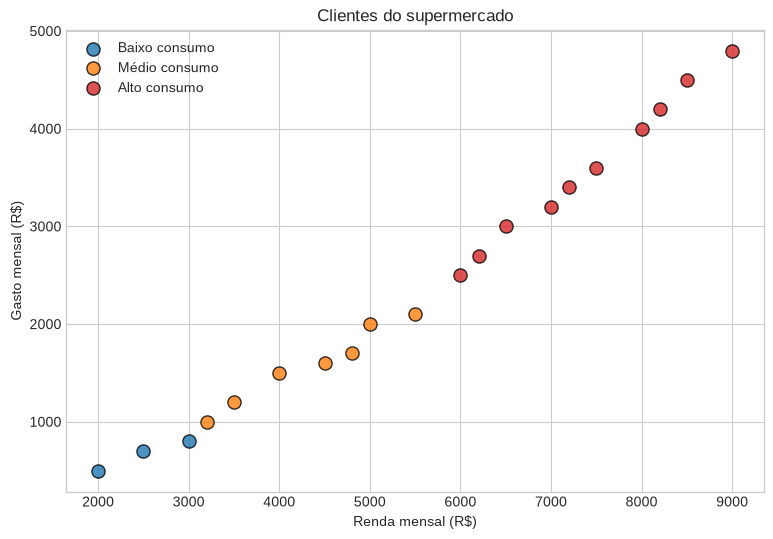

In [4]:
X1, y1 = carregar('exercicio_1.csv')
nomes1 = ('Renda mensal (R$)', 'Gasto mensal (R$)')
rotulos1 = {1: 'Baixo consumo', 2: 'Médio consumo', 3: 'Alto consumo'}
print(X1.shape, np.bincount(y1)[1:])
plotar_dados(X1, y1, nomes1, rotulos1, 'Clientes do supermercado')

**Acurácia para diferentes valores de k** (leave-one-out, com e sem padronização das variáveis):

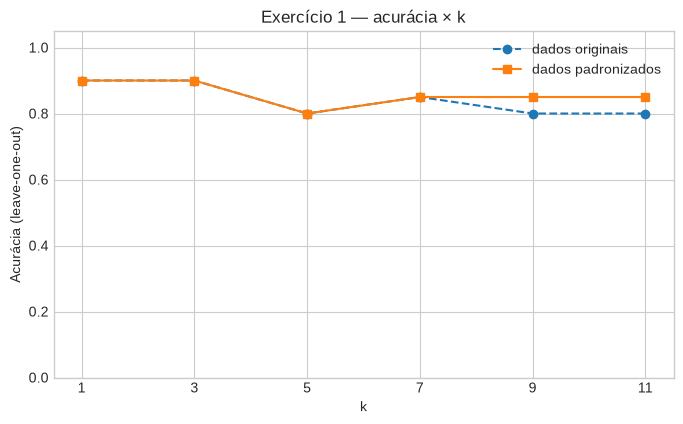

k  | original | padronizado
1  |      90% |      90%
3  |      90% |      90%
5  |      80% |      80%
7  |      85% |      85%
9  |      80% |      85%
11 |      80% |      85%


In [5]:
plotar_acuracia_vs_k(X1, y1, [1, 3, 5, 7, 9, 11], 'Exercício 1 — acurácia × k')

**Fronteiras de decisão** para k pequeno, médio e grande (variáveis padronizadas):

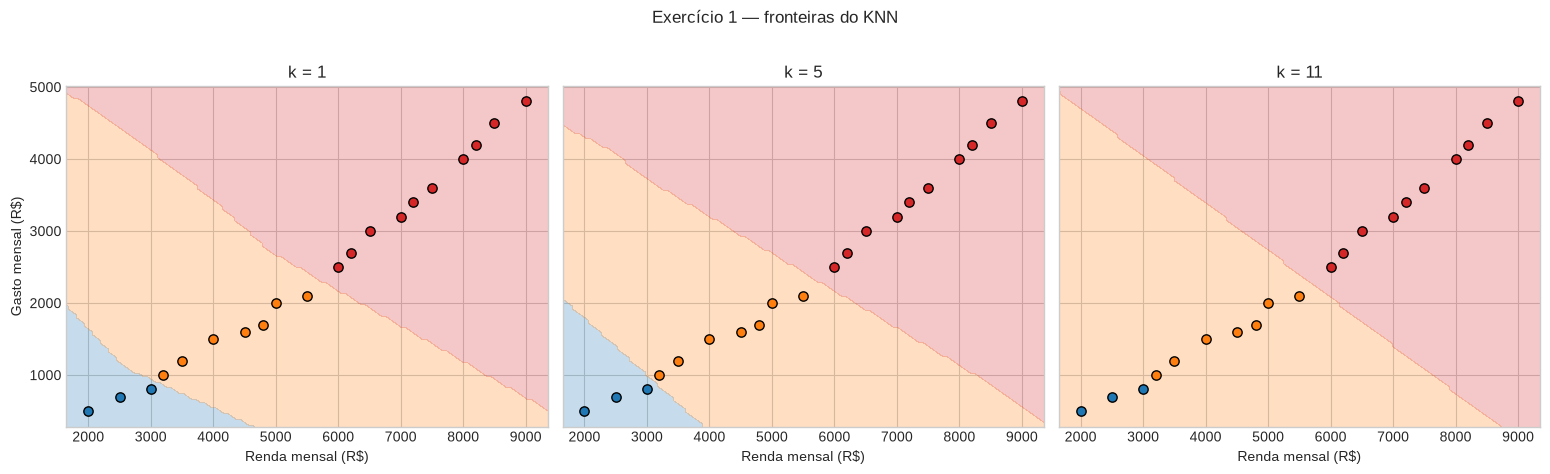

In [6]:
plotar_fronteiras(X1, y1, nomes1, [1, 5, 11], 'Exercício 1 — fronteiras do KNN')

**Matriz de confusão** (leave-one-out, padronizado, k = 3):

Acurácia com k=3: 90%


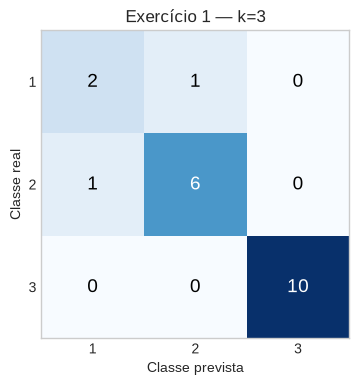

Pontos classificados errado (índice, valores, real -> previsto):
   2  [3000.  800.]  1 -> 2
   3  [3200. 1000.]  2 -> 1


In [7]:
Zn = normalizar(X1, X1.mean(0), X1.std(0))
acc, pred1 = acuracia_loo(Zn, y1, 3)
print(f'Acurácia com k=3: {acc:.0%}')
mostrar_confusao(matriz_confusao(y1, pred1), 'Exercício 1 — k=3')
erros = np.where(pred1 != y1)[0]
print('Pontos classificados errado (índice, valores, real -> previsto):')
for i in erros:
    print(f'  {i:2d}  {X1[i]}  {y1[i]} -> {pred1[i]}')

k= 1 -> classe 3  (vizinhos: [3])
k= 3 -> classe 3  (vizinhos: [3 3 2])
k= 5 -> classe 3  (vizinhos: [3 3 2 3 3])
k= 9 -> classe 3  (vizinhos: [3 3 2 3 3 3 2 2 3])
k=15 -> classe 3  (vizinhos: [3 3 2 3 3 3 2 2 3 2 3 2 3 2 3])


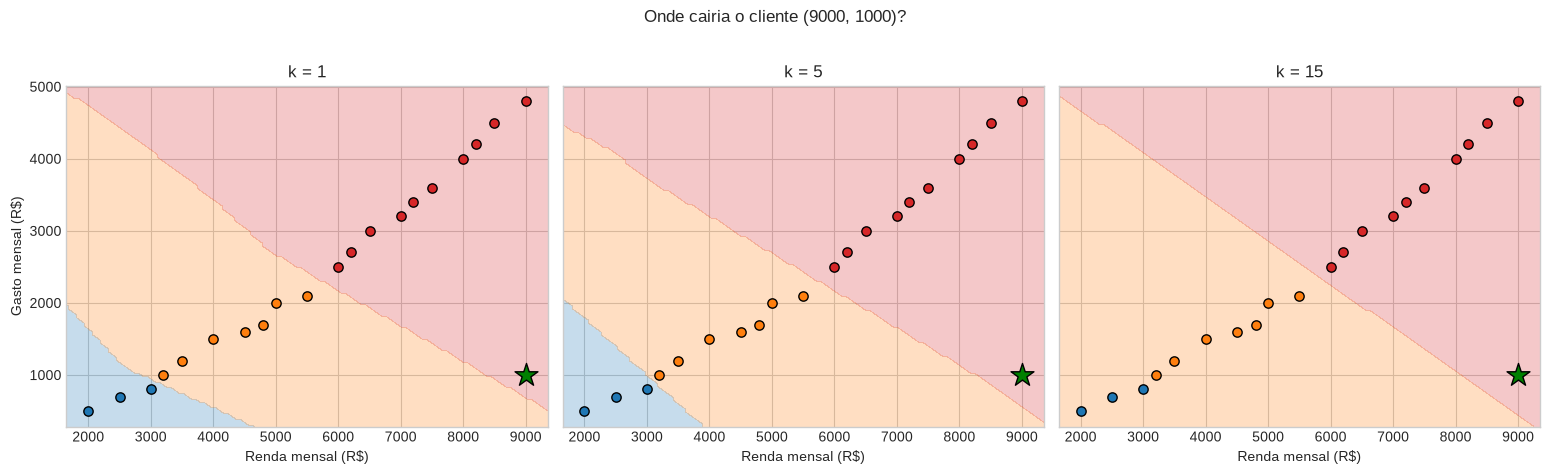

In [8]:
# Teste do quesito (b): cliente de renda alta e gasto baixo
Zs = normalizar(X1, X1.mean(0), X1.std(0))
cliente = np.array([9000, 1000])
for k in (1, 3, 5, 9, 15):
    rot, dist = vizinhos_mais_proximos(Zs, y1, normalizar(cliente, X1.mean(0), X1.std(0)), k)
    print(f'k={k:2d} -> classe {np.bincount(rot).argmax()}  (vizinhos: {rot})')
plotar_fronteiras(X1, y1, nomes1, [1, 5, 15], 'Onde cairia o cliente (9000, 1000)?', novo=cliente)

### Respostas — Exercício 1
**a) O KNN separou bem os grupos?** Sim. Com k = 1 ou 3 a acurácia (leave-one-out) é de **90 %** (18 de 20). Os três grupos formam faixas bem definidas e crescentes no gráfico (mais renda → mais gasto), e os únicos erros estão na **fronteira entre baixo e médio consumo** (clientes de renda 3000 e 3200), onde os pontos das duas classes estão a apenas ~200 R$ de distância um do outro. Alto consumo (classe 3) foi sempre classificado corretamente.

**b) Cliente de renda alta e gasto baixo pode ser classificado errado?** Pode. Nos dados, renda e gasto crescem juntos, então um cliente como (9000, 1000) está **fora da região onde existem dados de treino**: o KNN só olha para os vizinhos mais próximos e, nesse caso, os classificou como *alto consumo* (classe 3) simplesmente porque a renda é o que o aproxima dos clientes de alto consumo, mesmo com gasto baixo — uma previsão provavelmente errada. Isso mostra que a segmentação é **baseada em só duas variáveis**, que são fortemente correlacionadas: o modelo assume que "quem ganha mais gasta mais" e não sabe lidar com perfis que quebram esse padrão (ex.: cliente de alta renda e hábito econômico). Seria preciso mais atributos (tamanho da família, frequência de compra, etc.) e mais exemplos desse perfil.

**c) Influência de k na fronteira.** Nos gráficos vemos que:
- **k pequeno (1)**: a fronteira é irregular e "cola" em cada ponto, seguindo até ruídos (alta variância, risco de *overfitting*).
- **k grande (11+)**: a fronteira fica suave, mas as regiões estreitas (a classe 2, que tem só uma faixa intermediária) são "engolidas" pelas vizinhas; a acurácia cai para 80–85 %. (Alta tendência ao *underfitting*.)
- Um k intermediário (3) foi o melhor equilíbrio aqui (90 %) e, sendo ímpar, evita empates no voto.

# Exercício 2
Prever o nível de risco de crédito (1 = baixo, 2 = médio, 3 = alto) a partir de `Idade` e `Divida`.

(20, 2) [7 7 6]


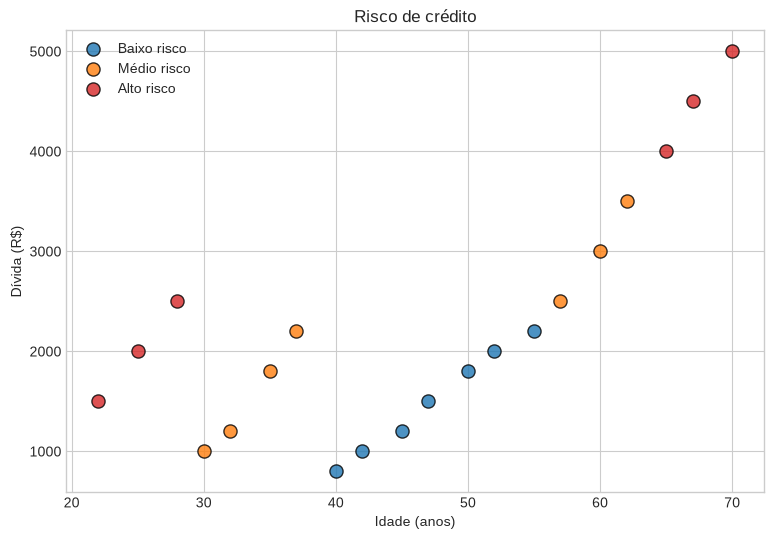

In [9]:
X2, y2 = carregar('exercicio_2.csv')
nomes2 = ('Idade (anos)', 'Dívida (R$)')
rotulos2 = {1: 'Baixo risco', 2: 'Médio risco', 3: 'Alto risco'}
print(X2.shape, np.bincount(y2)[1:])
plotar_dados(X2, y2, nomes2, rotulos2, 'Risco de crédito')

**Acurácia para diferentes valores de k** (leave-one-out, com e sem padronização das variáveis):

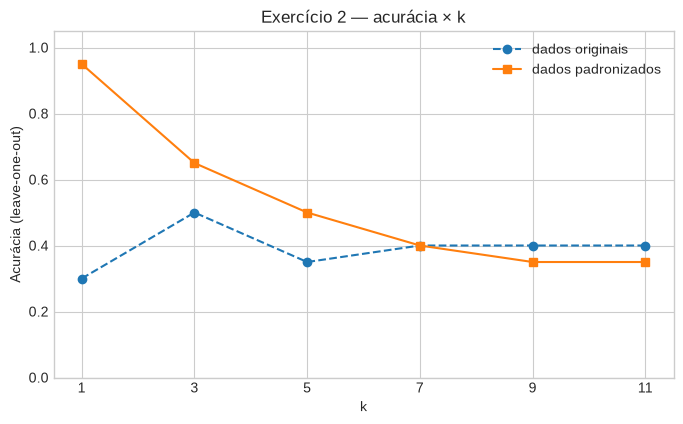

k  | original | padronizado
1  |      30% |      95%
3  |      50% |      65%
5  |      35% |      50%
7  |      40% |      40%
9  |      40% |      35%
11 |      40% |      35%


In [10]:
plotar_acuracia_vs_k(X2, y2, [1, 3, 5, 7, 9, 11], 'Exercício 2 — acurácia × k')

**Fronteiras de decisão** para k pequeno, médio e grande (variáveis padronizadas):

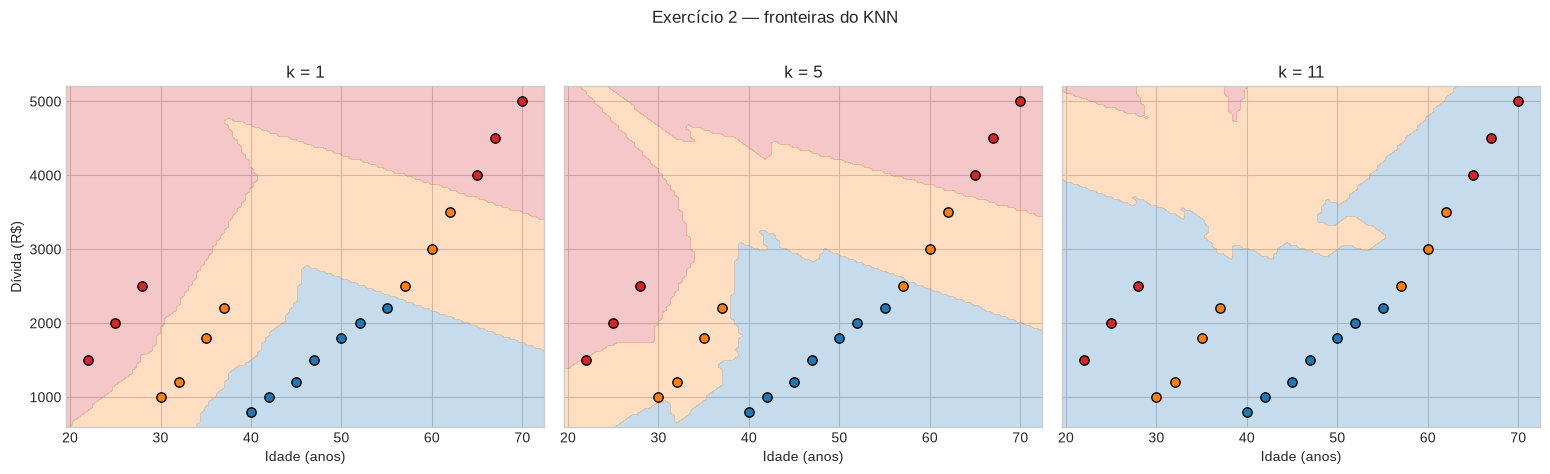

In [11]:
plotar_fronteiras(X2, y2, nomes2, [1, 5, 11], 'Exercício 2 — fronteiras do KNN')

**Matriz de confusão** (leave-one-out, padronizado, k = 1):

Acurácia com k=1: 95%


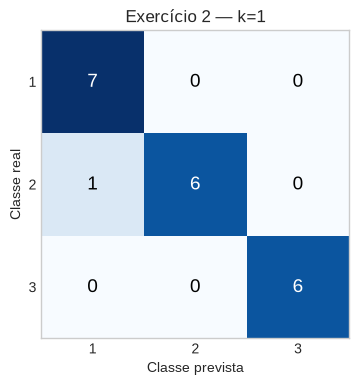

Pontos classificados errado (índice, valores, real -> previsto):
  14  [  57. 2500.]  2 -> 1


In [12]:
Zn = normalizar(X2, X2.mean(0), X2.std(0))
acc, pred2 = acuracia_loo(Zn, y2, 1)
print(f'Acurácia com k=1: {acc:.0%}')
mostrar_confusao(matriz_confusao(y2, pred2), 'Exercício 2 — k=1')
erros = np.where(pred2 != y2)[0]
print('Pontos classificados errado (índice, valores, real -> previsto):')
for i in erros:
    print(f'  {i:2d}  {X2[i]}  {y2[i]} -> {pred2[i]}')

### Respostas — Exercício 2
**a) Diferenciou bem alto risco de baixo risco?** Só com as variáveis **padronizadas** e k = 1 (95 %). Sem padronizar, a acurácia é de apenas **30 %**: `Divida` está na casa dos milhares e `Idade` na casa das dezenas, então a distância euclidiana é dominada pela dívida e a idade praticamente é ignorada. Mesmo padronizado, a relação é **não linear**: o risco é alto para jovens (22–28 anos), baixo para 40–55 anos e volta a ser alto para idosos com dívida grande (65–70 anos). Isso é uma estrutura em "U" que o KNN só capta com k muito pequeno, e como há apenas 20 pontos, um k=1 pode estar decorando os dados (a avaliação leave-one-out ajuda, mas o conjunto é muito pequeno).

**b) Há sobreposição do médio risco?** Sim. O grupo 2 aparece em **duas regiões separadas** (30–37 anos com dívida 1000–2200 e 57–62 anos com dívida 2500–3500), encostadas nas regiões do baixo risco (40–55 anos) e do alto risco (jovens e idosos com muita dívida). O único erro com k = 1 foi justamente um cliente de risco médio (57 anos, R$ 2500) confundido com o de baixo risco vizinho; para k maiores, muitos clientes do grupo 2 passam a ser "engolidos" pelos grupos vizinhos.

**c) Impacto de aumentar ou reduzir k.** Aqui a acurácia **cai à medida que k cresce** (padronizado: 95 % → 65 % → 50 % → 40 % → 35 % para k = 1, 3, 5, 7, 9/11). Como os grupos são pequenos e espalhados (só 6–7 clientes por classe), com k grande o voto passa a incluir vizinhos de outros grupos e a maioria vence errado. Reduzir k melhora a precisão neste conjunto, mas ao custo de sensibilidade a ruído; em dados reais, com mais registros, o k ideal seria maior e deveria ser escolhido por validação cruzada. Também fica evidente que **padronizar as variáveis é essencial** no KNN.

# Exercício 3
Classificar funcionários em níveis de desempenho (1 = baixo, 2 = médio, 3 = alto) a partir de `Horas_Treinamento` e `Projetos_Entregues`.

(20, 2) [4 7 9]


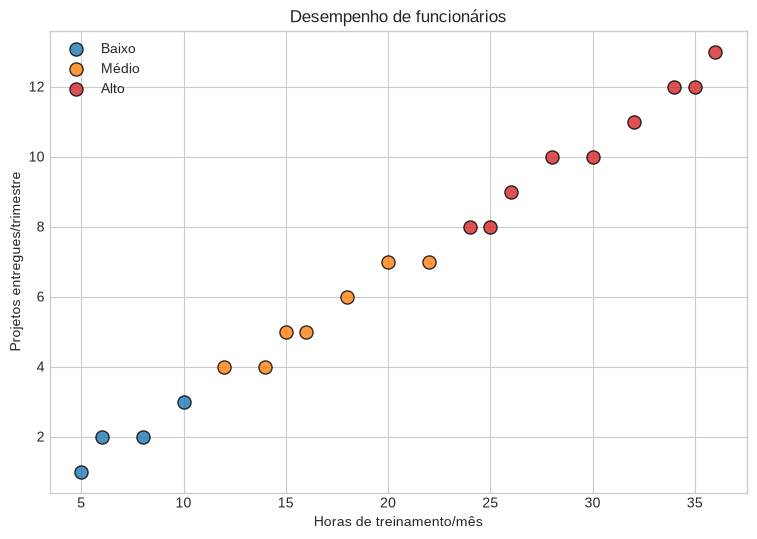

In [13]:
X3, y3 = carregar('exercicio_3.csv')
nomes3 = ('Horas de treinamento/mês', 'Projetos entregues/trimestre')
rotulos3 = {1: 'Baixo', 2: 'Médio', 3: 'Alto'}
print(X3.shape, np.bincount(y3)[1:])
plotar_dados(X3, y3, nomes3, rotulos3, 'Desempenho de funcionários')

**Acurácia para diferentes valores de k** (leave-one-out, com e sem padronização das variáveis):

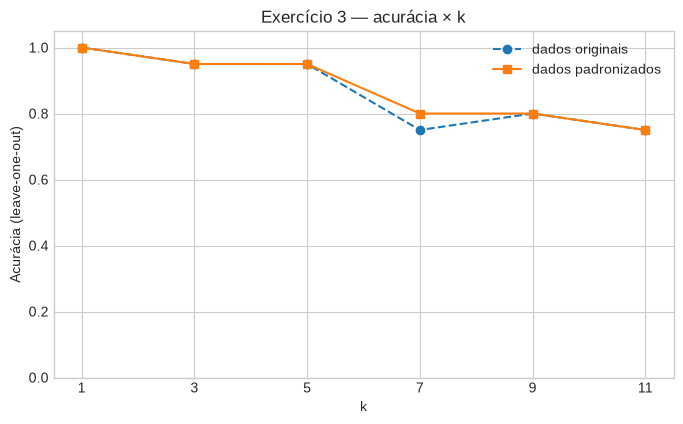

k  | original | padronizado
1  |     100% |     100%
3  |      95% |      95%
5  |      95% |      95%
7  |      75% |      80%
9  |      80% |      80%
11 |      75% |      75%


In [14]:
plotar_acuracia_vs_k(X3, y3, [1, 3, 5, 7, 9, 11], 'Exercício 3 — acurácia × k')

**Fronteiras de decisão** para k pequeno, médio e grande (variáveis padronizadas):

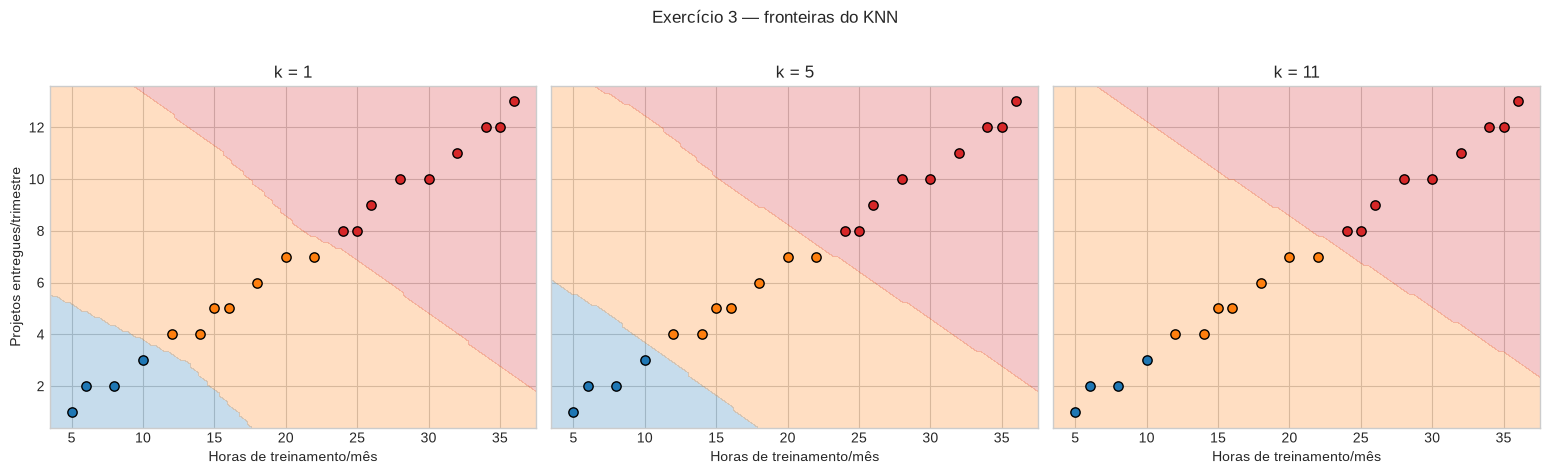

In [15]:
plotar_fronteiras(X3, y3, nomes3, [1, 5, 11], 'Exercício 3 — fronteiras do KNN')

**Matriz de confusão** (leave-one-out, padronizado, k = 3):

Acurácia com k=3: 95%


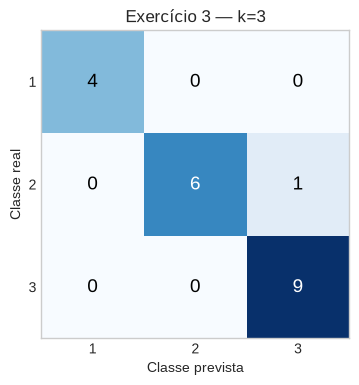

Pontos classificados errado (índice, valores, real -> previsto):
  10  [22.  7.]  2 -> 3


In [16]:
Zn = normalizar(X3, X3.mean(0), X3.std(0))
acc, pred3 = acuracia_loo(Zn, y3, 3)
print(f'Acurácia com k=3: {acc:.0%}')
mostrar_confusao(matriz_confusao(y3, pred3), 'Exercício 3 — k=3')
erros = np.where(pred3 != y3)[0]
print('Pontos classificados errado (índice, valores, real -> previsto):')
for i in erros:
    print(f'  {i:2d}  {X3[i]}  {y3[i]} -> {pred3[i]}')

k=1 -> classe 2  (vizinhos: [2])
k=3 -> classe 2  (vizinhos: [2 2 2])
k=5 -> classe 2  (vizinhos: [2 2 2 2 2])
k=7 -> classe 2  (vizinhos: [2 2 2 2 2 1 2])


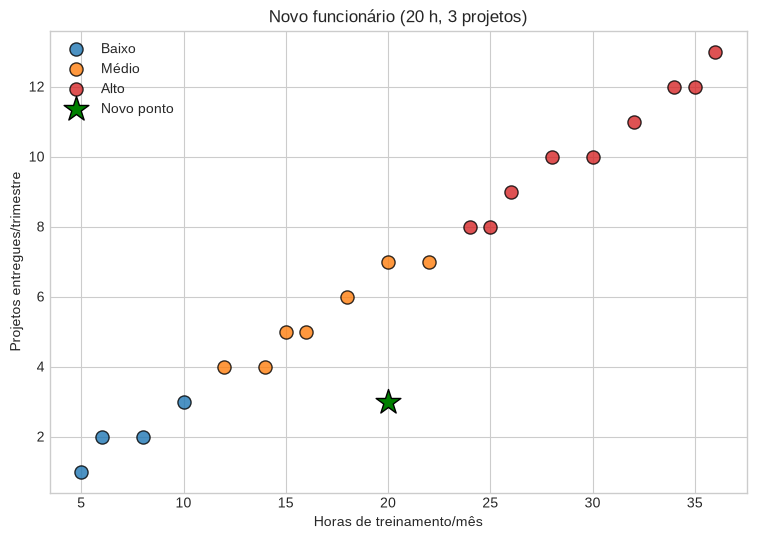

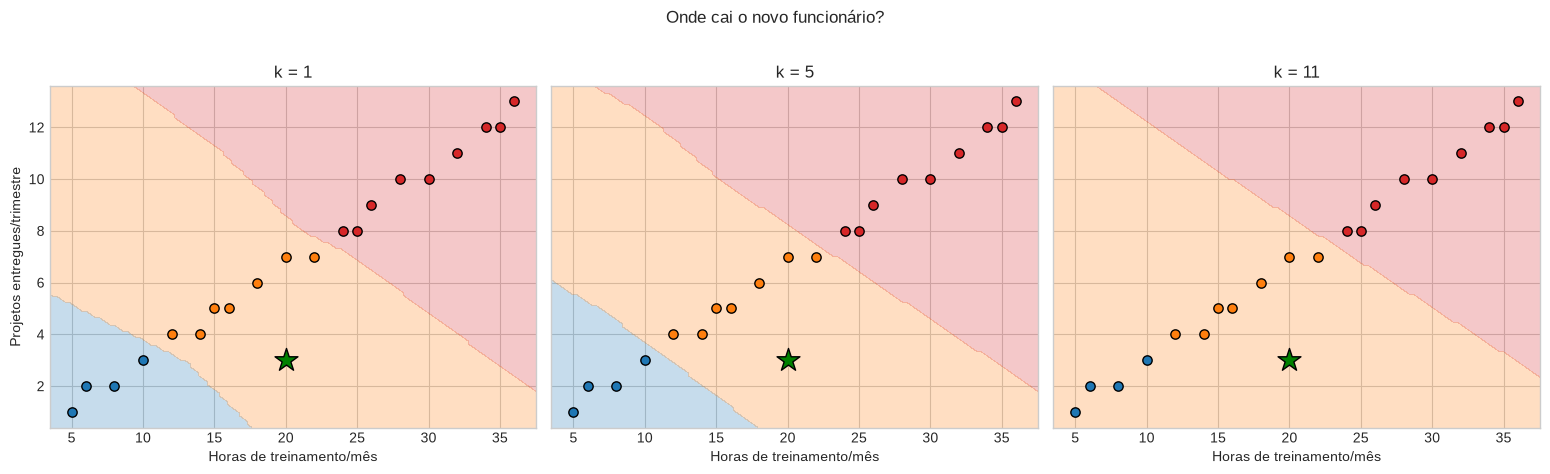

In [17]:
# Quesito (c): novo funcionário com 20 horas de treinamento e 3 projetos
novo = np.array([20, 3])
Zs = normalizar(X3, X3.mean(0), X3.std(0))
for k in (1, 3, 5, 7):
    rot, dist = vizinhos_mais_proximos(Zs, y3, normalizar(novo, X3.mean(0), X3.std(0)), k)
    print(f'k={k} -> classe {np.bincount(rot).argmax()}  (vizinhos: {rot})')
plotar_dados(X3, y3, nomes3, rotulos3, 'Novo funcionário (20 h, 3 projetos)', novo=novo)
plotar_fronteiras(X3, y3, nomes3, [1, 5, 11], 'Onde cai o novo funcionário?', novo=novo)

### Respostas — Exercício 3
**a) Separou corretamente os níveis?** Sim, muito bem: **100 %** de acurácia com k = 1 e **95 %** com k = 3 e 5 (leave-one-out). As duas variáveis crescem juntas, e os três níveis formam faixas quase lineares e bem separadas. O único erro com k = 3 foi o funcionário com 22 h e 7 projetos (nível 2), que fica na fronteira com o nível 3 e foi classificado como alto desempenho.

**b) Muitas horas de treinamento e poucos projetos podem ser classificados errado?** Sim. Nos dados, horas e projetos são quase proporcionais, então o modelo aprendeu "mais horas ⇒ melhor desempenho". Um funcionário com, digamos, 35 h e 3 projetos está longe de qualquer exemplo do treino e será classificado pela proximidade em `Horas_Treinamento` (isto é, como alto desempenho), embora sua entrega seja baixa. Isso sugere que os atributos são **redundantes** (correlacionados) e que a variável realmente ligada ao desempenho é `Projetos_Entregues`; horas de treinamento são um insumo, não um resultado. Um modelo melhor deveria usar atributos que distinguem esses perfis (por exemplo, projetos por hora de treinamento, complexidade dos projetos, tempo de casa).

**c) Novo funcionário: 20 horas e 3 projetos.** O KNN o classifica como **nível 2 (médio)** para todos os k testados (1, 3, 5 e 7), com todos os vizinhos mais próximos de nível 2, como mostra a saída da célula. Ele tem horas de médio desempenho, mas produção de baixo desempenho; portanto, é um caso atípico, e a classificação depende basicamente das horas de treinamento.